# Tutorial 3 — QSAR de regressao com interpretabilidade

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Victor-Mag/qsar-ml-tutoriais/blob/main/notebooks/03_qsar_regressao_interpretabilidade.ipynb)

**Objetivo:** predizer um valor continuo de bioatividade (pIC50) contra
*Mycobacterium tuberculosis*, interpretar o modelo com cautela e delimitar onde
suas predicoes deixam de ser confiaveis.

**Pre-requisitos:** [Tutorial 1](https://colab.research.google.com/github/Victor-Mag/qsar-ml-tutoriais/blob/main/notebooks/01_smiles_rdkit_fingerprints.ipynb) e
[Tutorial 2](https://colab.research.google.com/github/Victor-Mag/qsar-ml-tutoriais/blob/main/notebooks/02_qsar_classificacao.ipynb). Reusamos scaffold split e
validacao cruzada agrupada sem reexplicar do zero.

**Como rodar.** Clique no botao acima para abrir no Google Colab e execute as
celulas na ordem (ou *Ambiente de execucao > Executar tudo*). Nao e preciso
editar nada: a celula de setup instala as bibliotecas e baixa os dados. Este e o
notebook mais pesado dos tres — conte **cerca de 5 minutos** de execucao numa
CPU do Colab, a maior parte no calculo dos descritores para as ~4.000 moleculas.

**Dados:** `data/tutorial/tuberculose_regressao.csv` — cerca de 4.000 moleculas
com pIC50 agregado, de um recorte do ChEMBL para *M. tuberculosis*. A curadoria
ja aplicada esta descrita em
[data/tutorial/README.md](https://github.com/Victor-Mag/qsar-ml-tutoriais/blob/main/data/tutorial/README.md).

> **Enquadramento honesto.** O modelo preve pIC50 dentro do dominio quimico e
> experimental deste recorte. O pIC50 agrega ensaios heterogeneos; a
> extrapolacao para esqueletos ausentes do treino e pouco confiavel. A secao 12
> existe justamente para tornar esse limite mensuravel em vez de assumido.

**Roteiro:**

| Secao | Conteudo |
| --- | --- |
| 1 | Leitura e distribuicao do alvo |
| 2 | De IC50 a pIC50 |
| 3 | Descritores moleculares |
| 4 | Splits |
| 5 | Limpeza da matriz, ajustada **so no treino** |
| 6 | Treinamento dos modelos |
| 7 | Validacao cruzada |
| 8 | Metricas de regressao |
| 9 | Observado vs. predito |
| 10 | Analise de residuos |
| 11 | Interpretabilidade: importancia e SHAP |
| 12 | Dominio de aplicabilidade |
| 13 | Limitacoes e exercicios |


## 0. Setup


In [1]:
# Setup — rode esta celula primeiro.
#
# No Colab: clona o repositorio (que ja traz os CSVs do tutorial) e instala as
# bibliotecas que faltam. Leva cerca de um minuto na primeira execucao, e pode
# ser rodada de novo sem quebrar nada.
# Localmente: nao faz nada alem de importar — instale antes as dependencias com
# `pip install -e .` na raiz do repositorio clonado.
import os
import sys
import warnings
from collections import defaultdict
from pathlib import Path

REPO = "https://github.com/Victor-Mag/qsar-ml-tutoriais"
COLAB = "google.colab" in sys.modules

if COLAB:
    if not Path("/content/qsar-ml-tutoriais").exists():
        !git clone -q {REPO}.git /content/qsar-ml-tutoriais
    os.chdir("/content/qsar-ml-tutoriais")
    !pip install -q -r requirements-colab.txt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from scipy.stats import spearmanr
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
RDLogger.DisableLog("rdApp.*")

# Os CSVs ficam em data/tutorial/. O caminho relativo depende de onde o
# notebook foi aberto: a raiz do repositorio (Colab, depois do clone acima) ou
# a pasta notebooks/ (execucao local).
DATA_DIR = next(
    (p for p in [Path("data/tutorial"), Path("../data/tutorial")] if p.is_dir()), None
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Nao encontrei data/tutorial/. No Colab, execute esta celula desde o "
        "inicio; localmente, abra o notebook a partir da pasta notebooks/."
    )

print("Setup concluido. Dados em", DATA_DIR.as_posix() + "/")


Setup concluido. Dados em ../data/tutorial/


## 1. Leitura e distribuicao do alvo

Mudamos de problema: em vez de duas classes, agora existe um numero continuo a
prever. Isso muda as metricas, o tratamento dos dados e o que conta como erro.


In [2]:
dados = pd.read_csv(DATA_DIR / "tuberculose_regressao.csv")

print(f"{len(dados)} moleculas, {dados.shape[1]} colunas\n")
print(dados["pIC50"].describe().round(2).to_string())

dados.head(3)

4000 moleculas, 7 colunas

count    4000.00
mean        5.35
std         1.12
min        -1.09
25%         4.58
50%         5.20
75%         6.01
max         9.62


,molecule_chembl_id,rdkit_canonical_smiles,pIC50,pIC50_range,n_measurements,target_chembl_id,assay_chembl_id
0,CHEMBL4647549,COC(=O)c1cccc(COc2ccc([N+](=O)[O-])cc2)c1,4.455932,0.000000,1,CHEMBL6065,CHEMBL4625598
1,CHEMBL3449959,Cc1cc(C)c2cc(CNC(C)C)c3nn(C)c(=O)n3c2c1,4.752330,0.033305,2,CHEMBL4105939,CHEMBL4649965
2,CHEMBL574967,O=C(N/N=C/c1ccc(O)cc1)c1ccc(N2CCOCC2)cc1,0.115700,0.000000,1,CHEMBL360,CHEMBL1040362


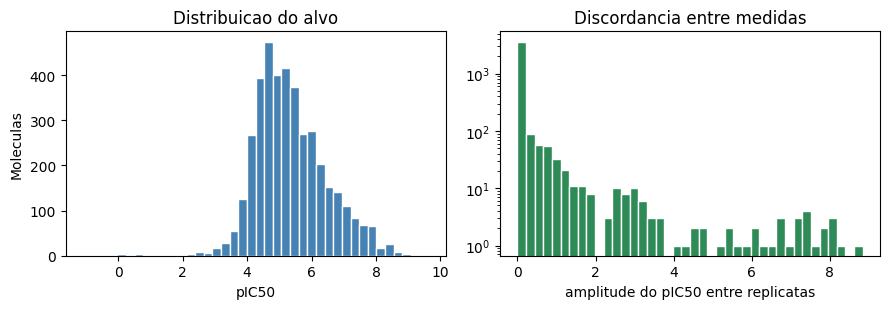

In [3]:
figura, eixos = plt.subplots(1, 2, figsize=(9, 3.2))

eixos[0].hist(dados["pIC50"], bins=40, color="steelblue", edgecolor="white")
eixos[0].set_xlabel("pIC50")
eixos[0].set_ylabel("Moleculas")
eixos[0].set_title("Distribuicao do alvo")

eixos[1].hist(dados["pIC50_range"], bins=40, color="seagreen", edgecolor="white")
eixos[1].set_xlabel("amplitude do pIC50 entre replicatas")
eixos[1].set_yscale("log")
eixos[1].set_title("Discordancia entre medidas")

figura.tight_layout()
plt.show()


A distribuicao se concentra entre 4 e 6,5. As caudas sao finas — ha poucas
moleculas muito potentes, que sao justamente as mais interessantes para
priorizacao. Guarde isso: qualquer modelo tera menos exemplos para aprender a
regiao que mais importa.


In [4]:
com_replicatas = dados[dados["n_measurements"] > 1]
discordantes = dados[dados["pIC50_range"] > 1.0]

print(f"moleculas com mais de uma medida: {len(com_replicatas)}")
print(f"moleculas com amplitude > 1 unidade de pIC50: {len(discordantes)}")
print(f"\nUma unidade de pIC50 = fator 10 na concentracao.")
print("Ou seja: ha moleculas cujas proprias medidas experimentais discordam")
print("por mais de 10x. Esse e o piso de erro que nenhum modelo pode superar.")

moleculas com mais de uma medida: 686
moleculas com amplitude > 1 unidade de pIC50: 139

Uma unidade de pIC50 = fator 10 na concentracao.
Ou seja: ha moleculas cujas proprias medidas experimentais discordam
por mais de 10x. Esse e o piso de erro que nenhum modelo pode superar.


> **Lição da secao 1.** O ruido experimental limita o desempenho maximo
> alcancavel. Se as replicatas de uma molecula discordam por 1 unidade de pIC50,
> exigir do modelo um erro menor que isso e exigir que ele acerte o ruido.


## 2. De IC50 a pIC50

O IC50 e a concentracao que inibe 50% da atividade. Ele **nao** e usado direto
como alvo de regressao. A transformacao padrao e:

$$\text{pIC50} = -\log_{10}(\text{IC50 em mol/L})$$

Tres motivos:

1. **Escala.** Valores de IC50 variam por ordens de grandeza (de nM a mM). Em
   escala linear, as moleculas fracas dominariam o erro quadratico.
2. **Simetria.** O log aproxima a distribuicao de uma normal, o que favorece
   praticamente todos os modelos.
3. **Interpretacao.** Uma unidade de pIC50 e sempre um fator 10, em qualquer
   ponto da escala. pIC50 maior = mais potente.


In [5]:
# Converte IC50 em nM para pIC50: nM -> M e uma divisao por 1e9; o sinal
# negativo inverte a escala, de modo que valores maiores passam a significar
# maior potencia.
for ic50 in [1, 10, 100, 1_000, 10_000, 100_000]:
    pic50 = -np.log10(ic50 * 1e-9)
    print(f"IC50 = {ic50:>7} nM  ->  pIC50 = {pic50:.2f}")


IC50 =       1 nM  ->  pIC50 = 9.00
IC50 =      10 nM  ->  pIC50 = 8.00
IC50 =     100 nM  ->  pIC50 = 7.00
IC50 =    1000 nM  ->  pIC50 = 6.00
IC50 =   10000 nM  ->  pIC50 = 5.00
IC50 =  100000 nM  ->  pIC50 = 4.00


Duas decisoes de curadoria ja aplicadas a estes dados, que voce precisaria tomar
num dataset cru:

- **Valores censurados descartados.** Registros anotados como `>10000 nM` nao dao
  um ponto numerico: sabe-se apenas que a atividade e pior que um limite. Manter
  o limite como se fosse a medida introduz vies sistematico. Neste recorte, todo
  IC50 coletado veio com relacao `=`, entao nada foi perdido.
- **Replicatas agregadas pela mediana.** Quando a mesma molecula tem varias
  medidas, o dataset guarda a mediana do pIC50 — mais robusta a outliers que a
  media. As colunas `pIC50_range` e `n_measurements` preservam a dispersao, para
  que a informacao descartada continue auditavel.

> **Lição da secao 2.** Toda regra de agregacao joga informacao fora. O minimo
> aceitavel e registrar qual regra foi usada e manter uma coluna que permita
> reconstruir o que foi perdido.


## 3. Descritores moleculares

O Tutorial 2 usou fingerprints de Morgan. Aqui usamos **descritores
fisico-quimicos**, e a troca e deliberada.

O objetivo desta secao e interpretar o modelo. Um valor SHAP para o "bit 1503 do
fingerprint" nao diz nada a um quimico. Um valor SHAP para "logP" ou "area polar
topologica" diz. Descritores custam poder preditivo em troca de legibilidade — e
neste tutorial a legibilidade e o ponto.

O RDKit calcula todos eles de uma vez com `CalcMolDescriptors`: mais de duzentas
colunas numa unica chamada (o numero exato depende da versao instalada, e sai
impresso abaixo).


In [6]:
# Celula mais lenta do notebook: alguns minutos no Colab para as ~4.000
# moleculas. E o preco de calcular a bateria completa de descritores.
moleculas = [Chem.MolFromSmiles(s) for s in dados["rdkit_canonical_smiles"]]
if any(m is None for m in moleculas):
    raise ValueError("SMILES invalido no dataset — rode a curadoria antes.")

descritores = pd.DataFrame([Descriptors.CalcMolDescriptors(m) for m in moleculas])
y = dados["pIC50"].to_numpy()

print("matriz bruta de descritores:", descritores.shape)
descritores.iloc[:3, :6]


matriz bruta de descritores: (4000, 217)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS
0,11.414333,11.414333,0.009295,-0.468638,0.479639,9.952381
1,12.498198,12.498198,0.100558,-0.100558,0.807009,11.909091
2,12.078116,12.078116,0.191244,-0.265226,0.665888,14.750000


## 4. Splits

Mesma logica do Tutorial 2: split aleatorio como referencia otimista, scaffold
split como avaliacao principal.

**Fazemos o split agora, antes de limpar a matriz de descritores.** A ordem nao
e cosmetica — a proxima secao explica por que inverte-la seria vazamento.


In [7]:
# Esqueleto Bemis-Murcko de cada molecula, ignorando estereoquimica.
valores_scaffold = []
for smiles in dados["rdkit_canonical_smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        valores_scaffold.append(f"SCAFFOLD_ERROR::{smiles}")
        continue
    try:
        esqueleto = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except (RuntimeError, ValueError):
        valores_scaffold.append(f"SCAFFOLD_ERROR::{smiles}")
        continue
    valores_scaffold.append(esqueleto if esqueleto else f"NO_SCAFFOLD::{smiles}")

scaffolds = pd.Series(valores_scaffold, index=dados.index)

# Maiores grupos no treino, series raras no teste (convencao da literatura).
test_size = 0.2

grupos = defaultdict(list)
for posicao, esqueleto in enumerate(scaffolds):
    grupos[esqueleto].append(posicao)

ordenados = sorted(grupos.values(), key=lambda ids: (-len(ids), min(ids)))
limite_treino = len(scaffolds) - round(len(scaffolds) * test_size)

treino, teste = [], []
for grupo in ordenados:
    if len(treino) + len(grupo) <= limite_treino:
        treino.extend(grupo)
    else:
        teste.extend(grupo)

idx_treino_scaffold = np.array(sorted(treino))
idx_teste_scaffold = np.array(sorted(teste))

idx_treino_aleatorio, idx_teste_aleatorio = train_test_split(
    np.arange(len(y)), test_size=test_size, random_state=RANDOM_STATE
)

n_tr_a, n_te_a = len(idx_treino_aleatorio), len(idx_teste_aleatorio)
n_tr_s, n_te_s = len(idx_treino_scaffold), len(idx_teste_scaffold)

print(f"{scaffolds.nunique()} esqueletos distintos")
print(f"aleatorio: {n_tr_a} treino / {n_te_a} teste")
print(f"scaffold:  {n_tr_s} treino / {n_te_s} teste")


1810 esqueletos distintos
aleatorio: 3200 treino / 800 teste
scaffold:  3200 treino / 800 teste


## 5. Limpeza da matriz, ajustada so no treino

Descritores brutos nao entram num modelo direto. Quatro filtros, nesta ordem:

1. **Colunas com `NaN` ou infinito.** Alguns descritores (cargas parciais, BCUT)
   falham em certas moleculas.
2. **Colunas constantes.** Variancia zero nao informa nada.
3. **Colunas de magnitude absurda.** Ver abaixo — o filtro parece dispensavel
   ate voce esbarrar no erro que ele evita.
4. **Colunas altamente correlacionadas** (|r| > 0,95). Colinearidade nao atrapalha
   muito arvores, mas distorce coeficientes lineares e, principalmente, **divide a
   importancia** entre descritores redundantes, atrapalhando a interpretacao.

### O ponto critico: quais estatisticas podem ser usadas

Todos esses filtros dependem de estatisticas dos dados (quais colunas tem NaN,
qual a variancia, qual a correlacao). Se elas forem calculadas sobre o dataset
**inteiro**, informacao do conjunto de teste vaza para dentro da decisao de quais
colunas o modelo enxerga — mesmo sem nenhum rotulo ser tocado.

E uma forma sutil de vazamento, e uma das causas mais comuns de desempenho
artificialmente alto em trabalhos de QSAR. Por isso as estatisticas saem **so do
treino**, e a mesma selecao e aplicada ao teste.


In [8]:
LIMITE_CORRELACAO = 0.95
LIMITE_MAGNITUDE = 1e10


def selecionar_colunas(tabela):
    """Aplica os quatro filtros e devolve (colunas mantidas, relatorio, extremos).

    O relatorio guarda quantas colunas sobraram apos cada etapa, para o processo
    ficar auditavel; `extremos` traz as colunas descartadas no filtro 3, com a
    magnitude que as condenou.
    """
    tabela = tabela.replace([np.inf, -np.inf], np.nan)
    relatorio = {"inicial": tabela.shape[1]}

    tabela = tabela.dropna(axis=1)
    relatorio["apos remover NaN/inf"] = tabela.shape[1]

    tabela = tabela.loc[:, tabela.nunique() > 1]
    relatorio["apos remover constantes"] = tabela.shape[1]

    magnitudes = tabela.abs().max()
    extremos = magnitudes[magnitudes > LIMITE_MAGNITUDE]
    tabela = tabela.loc[:, magnitudes <= LIMITE_MAGNITUDE]
    relatorio["apos remover magnitudes extremas"] = tabela.shape[1]

    correlacoes = tabela.corr().abs()
    triangulo = correlacoes.where(
        np.triu(np.ones(correlacoes.shape), k=1).astype(bool)
    )
    redundantes = [
        coluna
        for coluna in triangulo.columns
        if (triangulo[coluna] > LIMITE_CORRELACAO).any()
    ]
    tabela = tabela.drop(columns=redundantes)
    relatorio["apos remover correlacionadas"] = tabela.shape[1]

    return list(tabela.columns), relatorio, extremos


# So as linhas de treino entram na decisao de quais colunas manter.
colunas, relatorio, extremos = selecionar_colunas(descritores.iloc[idx_treino_scaffold])

for etapa, quantidade in relatorio.items():
    print(f"{etapa:<35} {quantidade:>4}")

print("\ndescartadas por magnitude extrema:")
for nome, valor in extremos.items():
    print(f"  {nome:<10} maior valor absoluto no treino = {valor:.1e}")


inicial                              217
apos remover NaN/inf                 205
apos remover constantes              195
apos remover magnitudes extremas     194
apos remover correlacionadas         158

descartadas por magnitude extrema:
  Ipc        maior valor absoluto no treino = 2.3e+39


### Por que o filtro de magnitude existe

Tire o passo 3 e o treino do Random Forest morre com
`Input X contains infinity or a value too large for dtype('float32')`.

O culpado e o descritor **`Ipc`** (*information content*), que cresce de forma
combinatoria com o tamanho da molecula e atinge, neste dataset, a magnitude
impressa na celula acima. Ele nao e `NaN`, nao e constante e nao e correlacionado
com nada — passa tranquilamente pelos outros tres filtros e so estoura na hora do
treino.

E um problema conhecido em QSAR e vale a licao geral: **inspecione a faixa de
valores dos seus descritores**, nao so a presenca de nulos.

Repare que o RDKit oferece tambem o `AvgIpc`, a versao do mesmo descritor
normalizada pelo numero de atomos. Essa variante e bem comportada, sobrevive aos
filtros e volta a aparecer la na secao 11 — o que descartamos foi a escala
explosiva, nao a informacao quimica.


In [9]:
X = descritores[colunas].to_numpy(dtype=np.float64)

print("X:", X.shape, "| y:", y.shape)
print(f"faixa de valores: {X.min():.2f} a {X.max():.2f}")
print("\nPrimeiros descritores mantidos:", colunas[:8])

X: (4000, 158) | y: (4000,)
faixa de valores: -55.97 a 5851.08

Primeiros descritores mantidos: ['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'FpDensityMorgan1', 'FpDensityMorgan2']


## 6. Treinamento dos modelos

Quatro modelos, nos dois splits:

- **`DummyRegressor(strategy="median")`** — sempre preve a mediana do treino. O
  piso obrigatorio. Note que seu R² e proximo de zero **por definicao**: R² mede
  exatamente quanto o modelo melhora sobre prever a media.
- **`Ridge`** — referencia linear, dentro de um `Pipeline` com `StandardScaler`.
  Descritores tem escalas muito diferentes (massa em centenas, contagens em
  unidades) e modelos lineares regularizados sao sensiveis a isso. O `Pipeline`
  garante que o scaler seja ajustado **so no treino** de cada fold.
- **`RandomForestRegressor`** e **`XGBRegressor`** — arvores, imunes a escala.


In [10]:
resultados, modelos_treinados = [], {}

for nome_split, (idx_tr, idx_te) in {
    "aleatorio": (idx_treino_aleatorio, idx_teste_aleatorio),
    "scaffold": (idx_treino_scaffold, idx_teste_scaffold),
}.items():
    # Instancias novas a cada split, para nao reaproveitar estado entre eles.
    modelos = {
        "Dummy": DummyRegressor(strategy="median"),
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_STATE,
            n_jobs=1,  # mantem o resultado bit a bit reproduzivel
        ),
    }

    for nome_modelo, modelo in modelos.items():
        modelo.fit(X[idx_tr], y[idx_tr])
        y_pred = modelo.predict(X[idx_te])
        y_teste_split = y[idx_te]

        # O Dummy preve sempre o mesmo valor. Correlacao de ranking com um
        # vetor constante e indefinida (nao existe ordem a comparar), entao
        # reportamos NaN em vez de deixar o scipy emitir aviso e devolver nan
        # silenciosamente.
        if np.ptp(y_pred) == 0:
            ranking = np.nan
        else:
            ranking = spearmanr(y_teste_split, y_pred).statistic

        metricas = {
            "RMSE": np.sqrt(mean_squared_error(y_teste_split, y_pred)),
            "MAE": mean_absolute_error(y_teste_split, y_pred),
            "R2": r2_score(y_teste_split, y_pred),
            "Spearman": ranking,
        }

        resultados.append({"split": nome_split, "modelo": nome_modelo, **metricas})
        modelos_treinados[(nome_split, nome_modelo)] = modelo

tabela = pd.DataFrame(resultados)
print("Treinamento concluido:", len(tabela), "combinacoes")


Treinamento concluido: 8 combinacoes


## 7. Validacao cruzada

Como no Tutorial 2, comparamos a CV ingenua (`KFold`) com a agrupada por
esqueleto (`GroupKFold`). A diferenca entre as duas mede o quanto a estimativa
ingenua se beneficia de ver series congeneres nos dois lados.


In [11]:
X_treino = X[idx_treino_scaffold]
y_treino = y[idx_treino_scaffold]
grupos_treino = scaffolds.iloc[idx_treino_scaffold].to_numpy()

modelo_cv = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)

cv_ingenua = cross_val_score(
    modelo_cv, X_treino, y_treino,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring="r2",
)
cv_agrupada = cross_val_score(
    modelo_cv, X_treino, y_treino,
    cv=GroupKFold(n_splits=5), groups=grupos_treino, scoring="r2",
)

print("R² em validacao cruzada (5 folds):")
print(f"  KFold (ingenua):          {cv_ingenua.mean():.3f}"
      f" +/- {cv_ingenua.std():.3f}")
print(f"  GroupKFold por esqueleto: {cv_agrupada.mean():.3f}"
      f" +/- {cv_agrupada.std():.3f}")
print(f"\n  folds ingenuos:  {np.round(cv_ingenua, 3)}")
print(f"  folds agrupados: {np.round(cv_agrupada, 3)}")

R² em validacao cruzada (5 folds):
  KFold (ingenua):          0.590 +/- 0.044
  GroupKFold por esqueleto: 0.339 +/- 0.079

  folds ingenuos:  [0.635 0.649 0.576 0.554 0.539]
  folds agrupados: [0.337 0.26  0.252 0.38  0.463]


## 8. Metricas de regressao

| Metrica | O que mede | Leitura |
| --- | --- | --- |
| **RMSE** | erro quadratico medio, na unidade do alvo | penaliza erros grandes |
| **MAE** | erro absoluto medio | mais robusto a outliers |
| **R²** | fracao da variancia explicada | 0 = igual a prever a media; **negativo = pior que isso** |
| **Spearman** | correlacao de ranking | o modelo **ordena** certo? |

Para priorizacao de compostos, **Spearman costuma importar mais que R²**: se voce
so vai testar o topo da lista, o que interessa e a ordem, nao o valor absoluto.


In [12]:
tabela.set_index(["split", "modelo"]).round(3)

RMSE    MAE     R2  Spearman
split     modelo                                     
aleatorio Dummy         1.101  0.832 -0.020       NaN
          Ridge         0.945  0.729  0.249     0.468
          RandomForest  0.710  0.525  0.576     0.702
          XGBoost       0.701  0.516  0.586     0.705
scaffold  Dummy         1.133  0.882 -0.000       NaN
          Ridge         1.182  0.895 -0.088     0.301
          RandomForest  0.914  0.694  0.349     0.552
          XGBoost       0.928  0.703  0.329     0.514

In [13]:
comparacao = tabela.pivot(index="modelo", columns="split", values="R2").loc[
    ["Dummy", "Ridge", "RandomForest", "XGBoost"]
]
comparacao["queda"] = comparacao["aleatorio"] - comparacao["scaffold"]

print("R² por split:")
print(comparacao.round(3).to_string())

R² por split:
split         aleatorio  scaffold  queda
modelo                                  
Dummy            -0.020    -0.000 -0.020
Ridge             0.249    -0.088  0.337
RandomForest      0.576     0.349  0.227
XGBoost           0.586     0.329  0.257


## 9. Observado vs. predito

O grafico diagnostico padrao da regressao. A diagonal e a predicao perfeita.


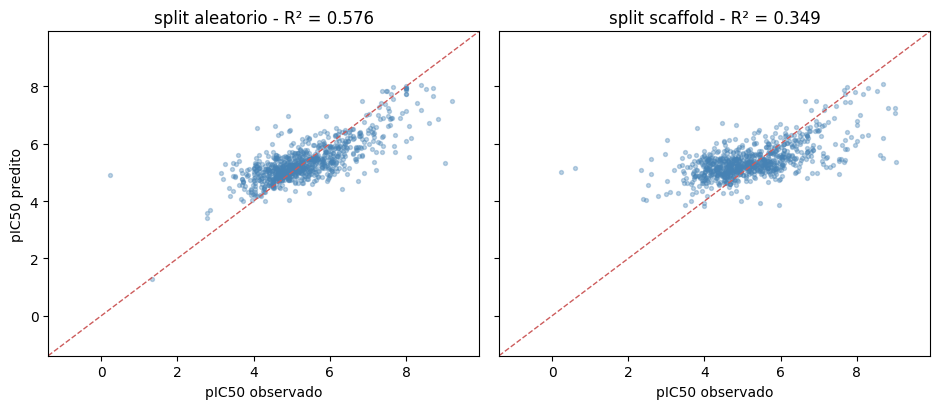

In [14]:
figura, eixos = plt.subplots(1, 2, figsize=(9.5, 4.2), sharex=True, sharey=True)

for eixo, nome_split, idx_te in zip(
    eixos, ["aleatorio", "scaffold"], [idx_teste_aleatorio, idx_teste_scaffold]
):
    modelo = modelos_treinados[(nome_split, "RandomForest")]
    y_verdadeiro, y_predito = y[idx_te], modelo.predict(X[idx_te])

    eixo.scatter(y_verdadeiro, y_predito, s=8, alpha=0.35, color="steelblue")
    limites = [y.min() - 0.3, y.max() + 0.3]
    eixo.plot(limites, limites, "--", color="indianred", linewidth=1)
    eixo.set_xlim(limites)
    eixo.set_ylim(limites)
    eixo.set_xlabel("pIC50 observado")
    r2 = r2_score(y_verdadeiro, y_predito)
    eixo.set_title(f"split {nome_split} - R² = {r2:.3f}")

eixos[0].set_ylabel("pIC50 predito")
figura.tight_layout()
plt.show()


Repare que a nuvem e **mais achatada que a diagonal**: o modelo subestima os
compostos muito potentes e superestima os muito fracos. Isso se chama **regressao
ao meio** e nao e um bug — e o comportamento esperado de um modelo que minimiza
erro quadratico com poucos exemplos nos extremos.

A consequencia pratica e desconfortavel: justamente as moleculas mais potentes,
que sao o alvo da busca, sao as que o modelo puxa para baixo.


## 10. Analise de residuos

O residuo e `observado - predito`. Analisar sua estrutura revela vieses que uma
metrica agregada esconde.


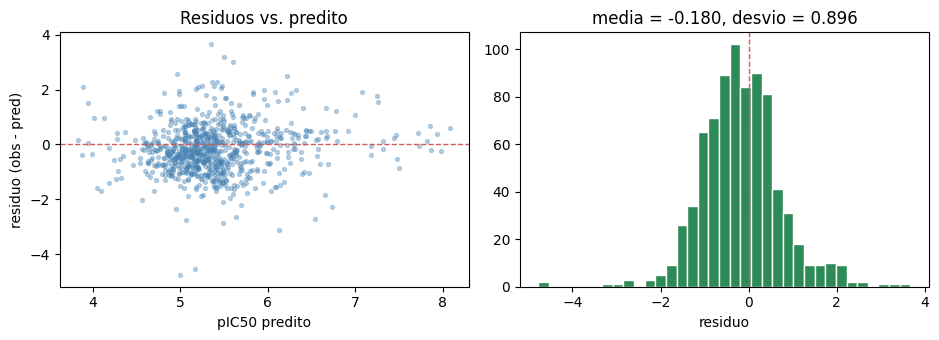

In [15]:
modelo_principal = modelos_treinados[("scaffold", "RandomForest")]
y_teste = y[idx_teste_scaffold]
y_predito = modelo_principal.predict(X[idx_teste_scaffold])
residuos = y_teste - y_predito

figura, eixos = plt.subplots(1, 2, figsize=(9.5, 3.5))

eixos[0].scatter(y_predito, residuos, s=8, alpha=0.35, color="steelblue")
eixos[0].axhline(0, color="indianred", linestyle="--", linewidth=1)
eixos[0].set_xlabel("pIC50 predito")
eixos[0].set_ylabel("residuo (obs - pred)")
eixos[0].set_title("Residuos vs. predito")

eixos[1].hist(residuos, bins=35, color="seagreen", edgecolor="white")
eixos[1].axvline(0, color="indianred", linestyle="--", linewidth=1)
eixos[1].set_xlabel("residuo")
eixos[1].set_title(f"media = {residuos.mean():.3f}, desvio = {residuos.std():.3f}")

figura.tight_layout()
plt.show()


In [16]:
# Erro por faixa de potencia: a pergunta que importa para priorizacao.
faixas = pd.cut(y_teste, bins=[-2, 4, 5, 6, 7, 11],
                labels=["< 4", "4–5", "5–6", "6–7", "> 7"])

por_faixa = pd.DataFrame({
    "faixa de pIC50": faixas,
    "erro_absoluto": np.abs(residuos),
    "residuo": residuos,
}).groupby("faixa de pIC50", observed=False).agg(
    n=("erro_absoluto", "size"),
    MAE=("erro_absoluto", "mean"),
    vies_medio=("residuo", "mean"),
).round(3)

print(por_faixa.to_string())
print("\nvies_medio > 0 => o modelo SUBESTIMA aquela faixa")

                  n    MAE  vies_medio
faixa de pIC50                        
< 4              82  1.424      -1.419
4–5             310  0.657      -0.636
5–6             239  0.358       0.116
6–7             115  0.637       0.584
> 7              54  1.413       1.387

vies_medio > 0 => o modelo SUBESTIMA aquela faixa


> **Lição da secao 10.** Um MAE global esconde que o erro nao e uniforme. Se o
> modelo erra mais e de forma enviesada exatamente na faixa de alta potencia, ele
> e menos util para priorizacao do que a metrica global sugere.


## 11. Interpretabilidade: importancia e SHAP

Tres visoes de "quais descritores importam", em ordem crescente de confiabilidade.

**1. Importancia por impureza** (`feature_importances_`). Sai de graca no treino,
mas tem vies conhecido: favorece variaveis continuas e de alta cardinalidade,
simplesmente porque elas oferecem mais pontos de corte possiveis.

**2. Importancia por permutacao.** Embaralha uma coluna por vez no conjunto de
**teste** e mede quanto o desempenho piora. Mais honesta, porque mede o que o
modelo realmente usa para generalizar. Custa mais tempo.

**3. Valores SHAP.** Atribuem a cada descritor, em cada predicao individual, uma
contribuicao com fundamentacao teorica. Permitem responder "por que **esta**
molecula recebeu **esta** predicao?".


In [17]:
modelo_xgb = modelos_treinados[("scaffold", "XGBoost")]
X_teste = X[idx_teste_scaffold]

# Toda esta secao explica o XGBoost, entao usamos as predicoes DELE — nao as do
# Random Forest da secao 10. Misturar os dois faria as contribuicoes SHAP nao
# fecharem com o valor predito.
y_predito_xgb = modelo_xgb.predict(X_teste)

# 1. Impureza (do proprio modelo de arvore).
imp_impureza = pd.Series(modelo_xgb.feature_importances_, index=colunas)

# 2. Permutacao. n_repeats=5 e n_jobs=1 mantem a celula rapida: com poucas
# repeticoes, o custo de criar processos paralelos nao se paga.
perm = permutation_importance(
    modelo_xgb, X_teste, y_teste, n_repeats=5, random_state=RANDOM_STATE, n_jobs=1
)
imp_permutacao = pd.Series(perm.importances_mean, index=colunas)

comparacao_imp = pd.DataFrame({
    "impureza": imp_impureza,
    "permutacao": imp_permutacao,
}).sort_values("permutacao", ascending=False).head(12)

comparacao_imp.round(4)


,impureza,permutacao
fr_Ndealkylation2,0.1173,0.0674
PEOE_VSA4,0.0519,0.0519
BertzCT,0.0036,0.0375
SlogP_VSA8,0.0152,0.0330
SMR_VSA9,0.0041,0.0172
PEOE_VSA8,0.0026,0.0143
MaxAbsEStateIndex,0.0006,0.0126
fr_Ar_NH,0.0261,0.0120
fr_allylic_oxid,0.0363,0.0113
AvgIpc,0.0034,0.0106


In [18]:
# As duas visoes concordam no topo? A sobreposicao dos 10 primeiros responde.
topo_impureza = set(imp_impureza.nlargest(10).index)
topo_permutacao = set(imp_permutacao.nlargest(10).index)

print(f"descritores em ambos os top 10: {len(topo_impureza & topo_permutacao)}")
print(f"so na impureza:   {sorted(topo_impureza - topo_permutacao)}")
print(f"so na permutacao: {sorted(topo_permutacao - topo_impureza)}")

descritores em ambos os top 10: 4
so na impureza:   ['NumBridgeheadAtoms', 'fr_Al_COO', 'fr_Ar_N', 'fr_hdrzone', 'fr_morpholine', 'fr_oxazole']
so na permutacao: ['AvgIpc', 'BertzCT', 'MaxAbsEStateIndex', 'PEOE_VSA8', 'SMR_VSA9', 'SlogP_VSA8']


matriz de valores SHAP: (800, 158) (moleculas x descritores)


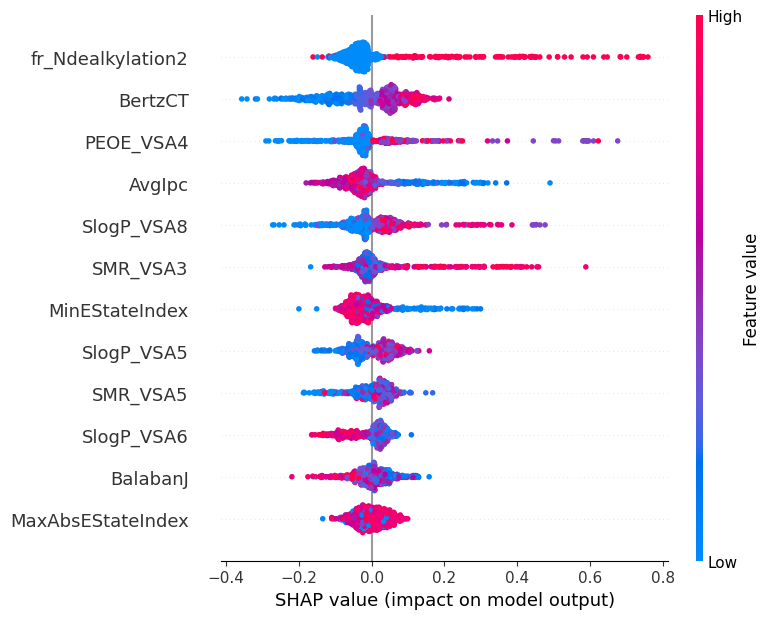

In [19]:
# 3. SHAP. TreeExplainer e exato e rapido para modelos de arvore.
explicador = shap.TreeExplainer(modelo_xgb)
valores_shap = explicador.shap_values(X_teste)

print("matriz de valores SHAP:", valores_shap.shape, "(moleculas x descritores)")

# O grafico beeswarm espalha os pontos verticalmente com jitter aleatorio, o que
# faria a figura mudar a cada execucao. O shap usa o gerador global antigo do
# numpy, entao fixamos a semente por ele.
#
# O numpy 2.x avisa que `np.random.seed` vai mudar de comportamento — e o proprio
# shap chama essa API internamente. Silenciamos o aviso porque a mensagem inclui
# o identificador do processo do kernel, que muda a cada execucao e sujaria o
# diff deste notebook, que e versionado com as saidas.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    np.random.seed(RANDOM_STATE)
    shap.summary_plot(
        valores_shap, X_teste, feature_names=colunas, max_display=12, show=False
    )

plt.tight_layout()
plt.show()


Como ler o grafico acima: cada ponto e uma molecula. A posicao horizontal e a
contribuicao daquele descritor para a predicao (direita = empurra o pIC50 para
cima). A cor e o valor do descritor (vermelho = alto, azul = baixo).

Um padrao "vermelho a direita, azul a esquerda" significa que valores altos
daquele descritor aumentam a potencia predita.


In [20]:
# SHAP tambem explica UMA predicao. Vamos pegar a molecula mais potente do teste.
posicao = int(np.argmax(y_teste))

contribuicoes = (
    pd.Series(valores_shap[posicao], index=colunas)
    .sort_values(key=np.abs, ascending=False)
    .head(8)
)

identificacao = dados.iloc[idx_teste_scaffold[posicao]]["molecule_chembl_id"]
base = explicador.expected_value
soma = valores_shap[posicao].sum()

print(f"molecula: {identificacao}")
print(f"pIC50 observado: {y_teste[posicao]:.2f}")
print(f"pIC50 predito (XGBoost): {y_predito_xgb[posicao]:.2f}")
print(f"\nvalor base (media do modelo):        {base:>6.2f}")
print(f"soma das contribuicoes SHAP:         {soma:>+6.2f}")
print(f"base + contribuicoes = predicao:     {base + soma:>6.2f}")
print("\nMaiores contribuicoes:")
print(contribuicoes.round(3).to_string())

molecula: CHEMBL5279457
pIC50 observado: 9.02
pIC50 predito (XGBoost): 6.30

valor base (media do modelo):          5.39
soma das contribuicoes SHAP:          +0.91
base + contribuicoes = predicao:       6.30

Maiores contribuicoes:
fr_ArN                     0.582
VSA_EState4                0.174
NumRotatableBonds          0.171
VSA_EState1                0.160
AvgIpc                    -0.085
EState_VSA10              -0.075
SlogP_VSA6                -0.072
NumAromaticHeterocycles    0.062


A conta fecha exatamente: **valor base + soma das contribuicoes = predicao**. Essa
e a propriedade que distingue SHAP de uma importancia qualquer — a decomposicao e
completa, nao aproximada.

Escolhemos de proposito a molecula **mais potente** do conjunto de teste, e o
resultado e revelador. As contribuicoes empurram a predicao para cima, na direcao
certa, mas somam menos de uma unidade de pIC50 — enquanto o valor observado esta
quase quatro unidades acima do valor base. O modelo reconheceu alguns sinais de
potencia e ainda assim errou por larga margem.

O SHAP esta explicando fielmente o que aconteceu: diante de uma molecula fora das
series que conhece, o modelo teve pouco em que se apoiar e ficou perto da media.
E a regressao ao meio da secao 9, agora vista molecula a molecula — e uma
antecipacao direta da secao 12.

Repare tambem no que isso significa para a leitura de um grafico SHAP: uma
contribuicao pode ser "a maior" e ainda assim ser pequena demais para levar a
predicao aonde ela precisaria chegar. Olhe a magnitude absoluta, nao so o
ranking.


> **Lição da secao 11.** SHAP explica o **modelo**, nao a quimica. Se o modelo
> aprendeu um atalho estatistico, o SHAP vai explicar fielmente o atalho. Um
> descritor com contribuicao alta esta **associado** a potencia no dataset de
> treino — o que nao significa que modifica-lo numa molecula real produziria o
> efeito previsto. Hipoteses vindas daqui precisam de teste experimental.


## 12. Dominio de aplicabilidade

Ate aqui medimos **quanto** o modelo erra em media. A pergunta desta secao e
diferente e mais util na pratica: **para quais moleculas podemos confiar nele?**

A ideia do dominio de aplicabilidade e simples: um modelo aprende a partir de uma
regiao do espaco quimico. Quanto mais distante uma molecula nova estiver dessa
regiao, menos confiavel a predicao.

Vamos medir a distancia estruturalmente: para cada molecula do teste, calculamos
a **similaridade de Tanimoto com o vizinho mais proximo do treino** (fingerprints
de Morgan, como no Tutorial 1) e cruzamos com o erro absoluto observado.

> Note que usamos fingerprints aqui mesmo tendo treinado o modelo com
> descritores. Nao ha contradicao: o dominio de aplicabilidade e uma pergunta
> sobre **semelhanca estrutural**, e fingerprints medem isso melhor.


In [21]:
gerador = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fingerprints = [
    gerador.GetFingerprint(Chem.MolFromSmiles(s))
    for s in dados["rdkit_canonical_smiles"]
]

fps_treino = [fingerprints[i] for i in idx_treino_scaffold]

similaridade_vizinho = np.array([
    max(DataStructs.BulkTanimotoSimilarity(fingerprints[i], fps_treino))
    for i in idx_teste_scaffold
])

print("Similaridade com o vizinho mais proximo do treino:")
print(pd.Series(similaridade_vizinho).describe().round(3).to_string())

Similaridade com o vizinho mais proximo do treino:
count    800.000
mean       0.531
std        0.213
min        0.135
25%        0.329
50%        0.513
75%        0.725
max        1.000


In [22]:
erro_absoluto = np.abs(residuos)

analise_dominio = pd.DataFrame({
    "similaridade": pd.cut(
        similaridade_vizinho,
        bins=[0, 0.3, 0.4, 0.5, 0.7, 1.0],
        labels=["< 0,3", "0,3–0,4", "0,4–0,5", "0,5–0,7", "> 0,7"],
    ),
    "erro_absoluto": erro_absoluto,
}).groupby("similaridade", observed=False).agg(
    n=("erro_absoluto", "size"),
    MAE=("erro_absoluto", "mean"),
    erro_mediano=("erro_absoluto", "median"),
).round(3)

print(analise_dominio.to_string())

correlacao = spearmanr(similaridade_vizinho, erro_absoluto)
print(f"\nSpearman(similaridade, erro absoluto) = {correlacao.statistic:.3f}")
print(f"p-valor = {correlacao.pvalue:.2e}")

                n    MAE  erro_mediano
similaridade                          
< 0,3         130  0.807         0.676
0,3–0,4       180  0.788         0.723
0,4–0,5        83  0.723         0.572
0,5–0,7       185  0.633         0.480
> 0,7         222  0.594         0.443

Spearman(similaridade, erro absoluto) = -0.186
p-valor = 1.22e-07


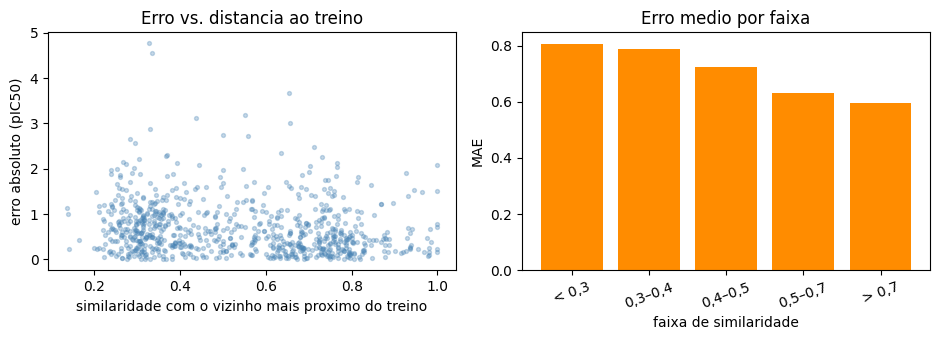

In [23]:
figura, eixos = plt.subplots(1, 2, figsize=(9.5, 3.5))

eixos[0].scatter(similaridade_vizinho, erro_absoluto, s=8, alpha=0.3, color="steelblue")
eixos[0].set_xlabel("similaridade com o vizinho mais proximo do treino")
eixos[0].set_ylabel("erro absoluto (pIC50)")
eixos[0].set_title("Erro vs. distancia ao treino")

validos = analise_dominio.dropna()
eixos[1].bar(range(len(validos)), validos["MAE"], color="darkorange")
eixos[1].set_xticks(range(len(validos)), validos.index, rotation=20)
eixos[1].set_xlabel("faixa de similaridade")
eixos[1].set_ylabel("MAE")
eixos[1].set_title("Erro medio por faixa")

figura.tight_layout()
plt.show()


### Como transformar isso numa regra de recusa

Um modelo maduro nao preve tudo: ele **recusa** o que esta fora do seu dominio.
A tabela acima permite escolher um limiar de similaridade e reportar a cobertura
que ele custa.


In [24]:
print(f"{'limiar':>8} {'cobertura':>10} {'MAE dentro':>11} {'MAE fora':>10}")
print("-" * 43)
for limiar in [0.0, 0.3, 0.4, 0.5]:
    dentro = similaridade_vizinho >= limiar
    mae_dentro = f"{erro_absoluto[dentro].mean():.3f}" if dentro.any() else "—"
    mae_fora = f"{erro_absoluto[~dentro].mean():.3f}" if (~dentro).any() else "—"
    print(f"{limiar:>8.1f} {dentro.mean():>9.1%} {mae_dentro:>11} {mae_fora:>10}")

  limiar  cobertura  MAE dentro   MAE fora
-------------------------------------------
     0.0    100.0%       0.694          —
     0.3     84.1%       0.673      0.808
     0.4     62.0%       0.631      0.798
     0.5     51.9%       0.619      0.775


> **Lição da secao 12.** "O modelo tem MAE de X" e uma frase incompleta. A frase
> util e "o modelo tem MAE de X para moleculas com similaridade >= Y ao treino, o
> que cobre Z% dos casos". Sem isso, a predicao para uma molecula
> estruturalmente inedita e apresentada com a mesma confianca de uma que o modelo
> praticamente ja viu.


## 13. Limitacoes e leitura critica

O que este modelo **e**: um baseline QSAR reproduzivel de potencia
antituberculosidica no recorte do ChEMBL usado aqui.

O que ele **nao e**: um preditor de pIC50 para qualquer composto contra
*M. tuberculosis*.

- **Ensaios heterogeneos.** O pIC50 agrega medidas de alvos moleculares e de
  inibicao de crescimento celular, em cepas e condicoes diferentes. Parte do erro
  do modelo e ruido sistematico dessa mistura, nao falha do algoritmo.
- **Piso de ruido experimental.** Como a secao 1 mostrou, ha moleculas cujas
  proprias replicatas discordam por mais de uma unidade de pIC50.
- **R² do split aleatorio e otimista.** So tem sentido lido contra o scaffold
  split.
- **Regressao ao meio.** O modelo comprime os extremos, justamente onde estao os
  compostos interessantes.
- **Dominio de aplicabilidade estreito.** Fora da vizinhanca quimica do treino, a
  predicao degrada de forma mensuravel (secao 12).
- **SHAP explica o modelo, nao o mecanismo.** Nenhuma hipotese daqui dispensa
  validacao experimental.

---

## Fim da sequencia

Voce percorreu o caminho completo: representacao molecular (Tutorial 1),
classificacao com avaliacao honesta (Tutorial 2) e regressao com interpretacao e
limites explicitos (Tutorial 3).

A mensagem que amarra os tres: **o valor cientifico de um modelo QSAR nao esta na
metrica, e na coerencia do pipeline inteiro** — curadoria, representacao, split,
validacao, interpretacao e dominio de aplicabilidade.

Para levar isto para os seus proprios dados, troque o CSV de entrada e mantenha o
resto: a curadoria, o scaffold split, o piso do modelo trivial e a analise de
dominio de aplicabilidade sao independentes do alvo biologico.

A procedencia dos dados, a licenca e as instrucoes de execucao local estao no
[README do repositorio](https://github.com/Victor-Mag/qsar-ml-tutoriais/blob/main/README.md).


---

## Exercicios

Todos usam variaveis definidas nas celulas acima, entao rode o notebook inteiro
antes.

### Exercicio 1

O `DummyRegressor` tem R² proximo de zero, as vezes ligeiramente negativo. Por
que ele nao da exatamente zero?

<details>
<summary>Solucao</summary>

```python
print(tabela[tabela["modelo"] == "Dummy"][["split", "R2", "RMSE"]].round(4).to_string(index=False))
```

Usamos `strategy="median"`, mas o R² e definido em relacao a **media**. Prever a
mediana do treino nao e o mesmo que prever a media do teste, entao o R² fica um
pouco abaixo de zero. Trocar para `strategy="mean"` aproxima de zero — mas a
mediana e mais robusta a outliers, e o objetivo do Dummy e ser um piso honesto,
nao maximizar R².

</details>

### Exercicio 2

Refaca a selecao de colunas usando o dataset **inteiro** em vez de so o treino, e
compare quantas colunas sobrevivem. O R² do scaffold split muda?

<details>
<summary>Solucao</summary>

```python
colunas_vazadas, _, _ = selecionar_colunas(descritores)
print(f"colunas com estatisticas do treino:  {len(colunas)}")
print(f"colunas com estatisticas do dataset: {len(colunas_vazadas)}")

X_vazado = descritores[colunas_vazadas].to_numpy(dtype=np.float64)
modelo = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
).fit(X_vazado[idx_treino_scaffold], y[idx_treino_scaffold])

r2_vazado = r2_score(y[idx_teste_scaffold], modelo.predict(X_vazado[idx_teste_scaffold]))
r2_correto = tabela.query("split == 'scaffold' and modelo == 'RandomForest'")["R2"].iloc[0]
print(f"\nR² com vazamento na selecao: {r2_vazado:.4f}")
print(f"R² sem vazamento:            {r2_correto:.4f}")
```

A diferenca costuma ser pequena — selecao de colunas vaza bem menos que, por
exemplo, ajustar um scaler no dataset todo. O ponto nao e o tamanho do efeito
aqui, e o **habito**: o mesmo descuido aplicado a normalizacao, imputacao ou
selecao supervisionada de atributos produz inflacoes muito maiores.

</details>

### Exercicio 3

Compare Spearman e R² do Ridge no scaffold split. Um modelo pode ordenar bem e
ainda assim ter R² ruim? O que isso significa para triagem?

<details>
<summary>Solucao</summary>

```python
print(tabela.query("split == 'scaffold'")[["modelo", "R2", "Spearman"]].round(3).to_string(index=False))
```

Sim, e e comum. R² penaliza erro na **escala** absoluta; Spearman so olha a
**ordem**. Um modelo pode acertar quem e mais potente que quem, mas errar
sistematicamente o valor (por exemplo, comprimindo tudo em torno da media) — e
isso derruba o R² sem afetar muito o Spearman.

Para triagem virtual, onde voce so vai testar o topo da lista, o Spearman e o
numero mais relevante dos dois.

</details>

### Exercicio 4

Use o dominio de aplicabilidade para reportar o desempenho do modelo de forma
honesta: qual o MAE para moleculas com similaridade >= 0,4, e que fracao do teste
isso representa?

<details>
<summary>Solucao</summary>

```python
dentro = similaridade_vizinho >= 0.4
print(f"cobertura: {dentro.mean():.1%} do conjunto de teste")
print(f"MAE dentro do dominio: {erro_absoluto[dentro].mean():.3f}")
print(f"MAE fora do dominio:   {erro_absoluto[~dentro].mean():.3f}")
print(f"MAE global (enganoso): {erro_absoluto.mean():.3f}")
```

A frase honesta tem tres partes: o erro, o criterio de dominio e a cobertura. O
MAE global fica entre os dois valores e nao descreve bem nenhum dos dois grupos.

</details>